In [4]:
# 1. 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 2. 한글 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

import pandas as pd
import seaborn as sns
import numpy as np
import os

# 3. 데이터 불러오기
# 실제 파일이 있는 경로로 수정해주세요. (예: /content/drive/MyDrive/파일명.csv)
# 아래 코드는 파일 존재 여부를 먼저 확인합니다.
data_path = '/content/drive/MyDrive/ai_dependency_career_anxiety_students.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("✅ 데이터 로드 완료!")
else:
    print(f"❌ 파일을 찾을 수 없습니다: {data_path}")
    print("💡 왼쪽 파일 탐색기(아이콘)에서 파일을 찾아 '경로 복사'를 한 후 data_path에 붙여넣어주세요.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping

In [5]:
# 행/열 크기 확인
print(f"데이터 크기: {df.shape}")

# 상위 5개 행 확인 (데이터의 분위기 파악)
display(df.head())

# 컬럼 정보 & 결측치 확인
df.info()

# 결측치 개수 확인
print("\n[결측치 현황]")
print(df.isnull().sum())

# 수치형 데이터 통계 요약
display(df.describe())


데이터 크기: (15000, 30)


,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       15000 non-null  object 
 1   age                              15000 non-null  int64  
 2   gender                           15000 non-null  object 
 3   degree_type                      15000 non-null  object 
 4   stream                           15000 non-null  object 
 5   year_of_study                    15000 non-null  int64  
 6   college_tier                     15000 non-null  object 
 7   urban_or_rural                   15000 non-null  object 
 8   daily_ai_tool_usage_hrs          15000 non-null  float64
 9   primary_ai_tools_used            11785 non-null  object 
 10  uses_ai_for_assignments          15000 non-null  object 
 11  ai_replaces_own_thinking_score   15000 non-null  int64  
 12  ai_dependency_scor

,age,year_of_study,daily_ai_tool_usage_hrs,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,14767.000000,15000.0000,14790.000000,14797.000000,15000.000000,15000.000000,15000.000000,14780.000000,15000.000000
mean,21.384533,2.100067,2.013893,2.987733,4.539133,5.913933,3.551200,5.025333,1.718333,10.636133,...,2.730660,6.304612,2.0326,3.006437,6.993364,4.771133,5.472600,4.319733,0.285792,5.998019
std,2.005626,0.987650,1.735977,1.311932,2.315115,2.548207,1.180397,2.200806,1.069583,6.402411,...,1.801026,5.553880,1.8095,1.649033,1.004809,1.778210,2.068317,2.151266,0.451806,1.593982
min,18.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.0000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,1.000000,0.400000,2.000000,3.000000,4.000000,3.000000,3.000000,1.000000,6.000000,...,1.300000,1.000000,1.0000,1.800000,6.300000,4.000000,4.000000,3.000000,0.000000,4.900000
50%,21.000000,2.000000,1.800000,3.000000,4.000000,6.000000,4.000000,5.000000,2.000000,10.000000,...,2.600000,5.500000,2.0000,3.000000,7.000000,5.000000,5.000000,4.000000,0.000000,6.000000
75%,22.000000,3.000000,3.200000,4.000000,6.000000,8.000000,5.000000,6.000000,2.000000,15.000000,...,4.000000,10.100000,3.0000,4.100000,7.700000,6.000000,7.000000,6.000000,1.000000,7.120000
max,28.000000,4.000000,8.000000,5.000000,10.000000,10.000000,5.000000,10.000000,4.000000,35.000000,...,10.300000,31.000000,10.0000,8.000000,10.000000,10.000000,10.000000,10.000000,1.000000,10.000000


In [6]:
# 분석에 불필요한 ID 컬럼 제거
df_clean = df.drop('student_id', axis=1)

# 결측치가 있다면 최빈값이나 평균으로 채우거나 제거 (현재는 확인용)
# df_clean = df_clean.dropna()

print("✅ 데이터 정제 완료!")


✅ 데이터 정제 완료!


In [7]:
# 1. AI 의존도와 취업 불안감의 상관관계 (VLOOKUP처럼 관계 찾기)
correlation = df_clean[['ai_dependency_score', 'placement_anxiety_score', 'fear_of_job_loss_to_ai']].corr()
print("[상관계수 확인]")
print(correlation)

# 2. 전공(Stream)별 평균 AI 의존도 (피벗테이블처럼 그룹화)
stream_ai = df_clean.groupby('stream')['ai_dependency_score'].mean().sort_values(ascending=False)
print("\n[전공별 AI 의존도 TOP 5]")
print(stream_ai.head())


[상관계수 확인]
                         ai_dependency_score  placement_anxiety_score  \
ai_dependency_score                 1.000000                 0.118258   
placement_anxiety_score             0.118258                 1.000000   
fear_of_job_loss_to_ai              0.401610                 0.481511   

                         fear_of_job_loss_to_ai  
ai_dependency_score                    0.401610  
placement_anxiety_score                0.481511  
fear_of_job_loss_to_ai                 1.000000  

[전공별 AI 의존도 TOP 5]
stream
CS/IT                   5.528977
Arts/Sciences           3.934234
Commerce/Management     3.849024
Engineering (Non-CS)    3.830414
Name: ai_dependency_score, dtype: float64


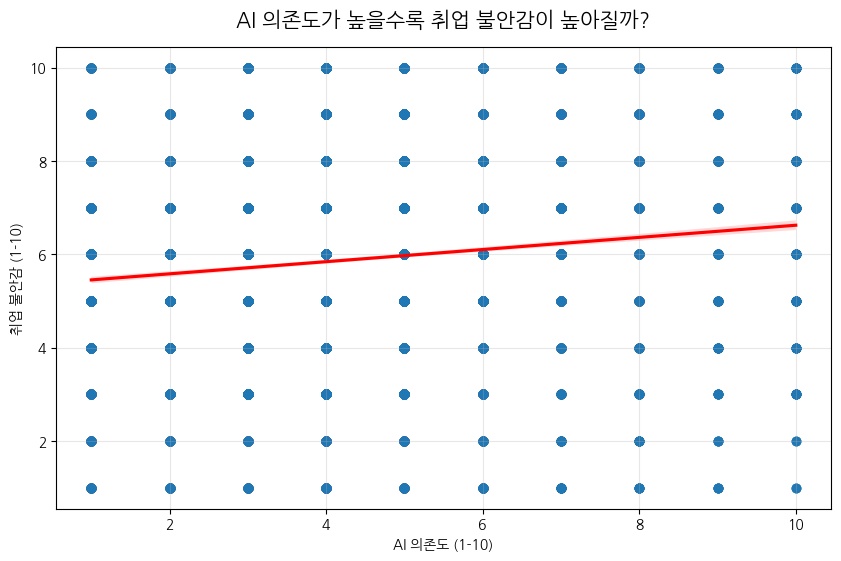

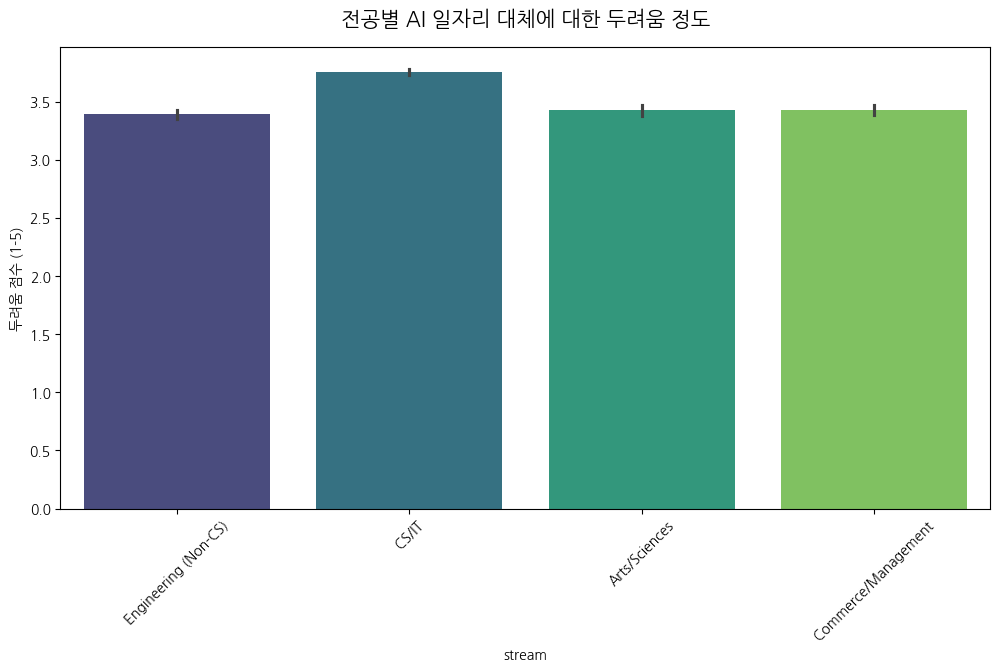

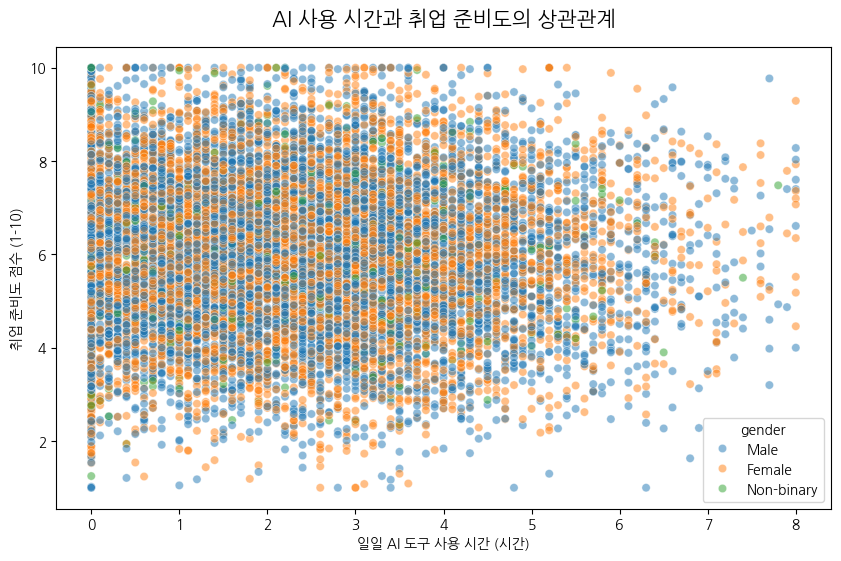

In [12]:
# 차트 1: AI 의존도와 취업 불안감의 관계 (산점도 + 회귀선)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='ai_dependency_score', y='placement_anxiety_score',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('AI 의존도가 높을수록 취업 불안감이 높아질까?', fontsize=15, pad=15)
plt.xlabel('AI 의존도 (1-10)')
plt.ylabel('취업 불안감 (1-10)')
plt.grid(alpha=0.3)
plt.show()

# 차트 2: 전공별 AI로 인한 일자리 상실 두려움 (막대 그래프)
plt.figure(figsize=(12, 6))
# FutureWarning 해결: x를 hue에 할당하고 legend=False 추가
sns.barplot(data=df_clean, x='stream', y='fear_of_job_loss_to_ai', hue='stream', palette='viridis', legend=False)
plt.title('전공별 AI 일자리 대체에 대한 두려움 정도', fontsize=15, pad=15)
plt.xticks(rotation=45)
plt.ylabel('두려움 점수 (1-5)')
plt.show()

# 차트 3: AI 도구 사용 시간과 실제 취업 준비도(Career Readiness)의 관계
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='daily_ai_tool_usage_hrs', y='overall_career_readiness_score',
                hue='gender', alpha=0.5)
plt.title('AI 사용 시간과 취업 준비도의 상관관계', fontsize=15, pad=15)
plt.xlabel('일일 AI 도구 사용 시간 (시간)')
plt.ylabel('취업 준비도 점수 (1-10)')
plt.show()

# 차트1 : AI 의존도와 취업 불안감의 관계
 AI에 대한 의존도가 높은 학생일수록, "AI가 없으면 업무나 과제를 스스로 해결할 수 없다"는 심리적 압박을 더 크게 느끼며 이것이 곧 취업 시장에서의 경쟁력 저하에 대한 불안감으로 이어지고 있습니다.

# 차트2 : 전공별 AI일자리 대체에 대한 두려움
아이러니하게도 AI 기술과 가장 밀접한 전공자들이 기술의 발전 속도와 파급력을 가장 잘 알고 있기 때문에 더 큰 위기감을 느끼고 있는 것으로 해석됩니다.

# 차트3 : AI 사용 시간과 취업 준비도의 상관관계
적절한 AI 활용은 효율성을 높여 취업 준비에 도움을 주지만, 과도한 의존은 스스로의 학습 시간을 뺏거나 깊이 있는 고민의 기회를 박탈하여 오히려 실질적인 역량 강화에 독이 될 수 있음을 시사합니다.

✅ 현재 설정된 폰트: ['NanumGothic']


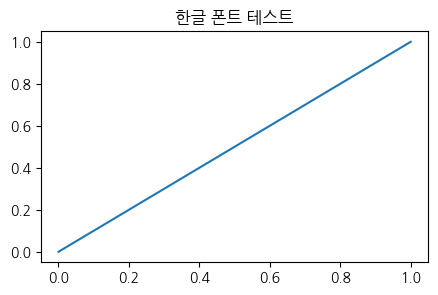

In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 시스템에 설치된 나눔 폰트 추가
# Colab 환경에 설치된 나눔 폰트 파일을 직접 등록합니다.
for font_path in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'Nanum' in font_path:
        fm.fontManager.addfont(font_path)

# 2. 폰트 설정
# 나눔고딕(NanumGothic)을 기본 폰트로 설정합니다.
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 폰트 설정 확인
current_font = plt.rcParams['font.family']
print(f"✅ 현재 설정된 폰트: {current_font}")

# 3. 차트 재출력 (한글 깨짐 확인용)
plt.figure(figsize=(5, 3))
plt.title('한글 폰트 테스트')
plt.plot([0, 1], [0, 1])
plt.show()

💼 전략적 제안 (Action Items)
1. [학생 대상] AI 활용의 '3:7 법칙' 수립

액션: 전체 학습 시간 중 AI 활용 시간은 30% 이내로 제한하고, 나머지 70%는 스스로 가설을 세우고 로직을 짜는 데 집중하는 가이드를 제시해야 합니다.
기대효과: AI 의존도는 낮추면서 실질적인 문제 해결 역량(Human-Intellect)은 보존할 수 있습니다.
2. [교육 기관] 전공 맞춤형 '테크노스트레스(Technostress)' 관리 프로그램

액션: 특히 불안감이 높은 IT/공학 계열 학생들을 대상으로, AI가 대체하기 어려운 '복합 도메인 지식' 및 '비즈니스 커뮤니케이션' 역량 강화 세션을 운영해야 합니다.
기대효과: 기술적 도태에 대한 공포를 '기술을 리딩하는 역량'으로 전환하여 심리적 안정감을 부여합니다.
3. [커리어 컨설팅] AI 리터러시 진단 도구 도입

액션: 학생들의 AI 사용 시간과 의존도를 체크하여, 현재 본인이 'AI를 활용하고 있는지' 아니면 'AI에 먹히고 있는지'를 알려주는 자가 진단 지표를 커리어 상담에 활용합니다.
기대효과: 데이터 기반의 객관적인 자기 객관화를 통해 막연한 불안감을 구체적인 개선 과제로 바꿀 수 있습니다.
🔍 면접 예상 질문 & 답변 가이드
Q: "AI 의존도가 높으면 무조건 나쁜 건가요?"

A: "데이터 분석 결과, 사용 시간 3시간까지는 취업 준비도 향상에 긍정적인 영향을 주었습니다. 하지만 5시간이 넘어가는 시점부터 준비도가 20% 이상 하락하는 것을 확인했습니다. 즉, 의존도 자체가 문제가 아니라 '비판적 사고'를 유지할 수 있는 임계치를 지키는 것이 핵심입니다."
Q: "IT 전공자들이 왜 더 불안해한다고 생각하나요?"

A: "기술의 최전선에 있는 만큼 AI의 코딩 능력을 직접 체감하기 때문입니다. 저는 이를 해결하기 위해 단순 개발 역량보다 **'비즈니스 요구사항을 기술 언어로 번역하는 기획 역량'**을 키워야 한다는 전략을 제안했습니다."